# BNCC Machine Learning Workshop: Regression

Pada notebook ini, kita akan mempelajari alur kerja machine learning untuk masalah regresi secara end-to-end. Tujuannya adalah membangun model yang dapat memprediksi harga rumah berdasarkan fitur-fitur yang tersedia di dataset.

Kita akan mulai dari memahami data, membersihkan data, melakukan feature engineering, menyiapkan preprocessing, melatih model, lalu mengevaluasi hasil prediksi.

In [1]:
print("Welcome to BNCC Machine Learning Workshop - Regression")

Welcome to BNCC Machine Learning Workshop - Regression


Sebelum membangun model, kita perlu mengetahui sumber data yang digunakan. Dataset pada notebook ini berisi data harga rumah di Jakarta beserta beberapa fitur seperti lokasi, jumlah kamar, luas tanah, dan luas bangunan.

Informasi sumber dataset penting supaya analisis kita bisa ditelusuri kembali dan peserta memahami konteks data yang sedang dipelajari.

Link Dataset: https://www.kaggle.com/datasets/abiyyurasyiq/jakarta-house-price-dataset/data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

## Memuat Dataset

Pada bagian ini, kita mulai memuat file dataset ke dalam pandas DataFrame. Setelah data berhasil dibaca, tampilkan beberapa baris pertama dan memastikan kolom-kolomnya sudah sesuai.

In [3]:
# TODO: lengkapi kode berikut untuk memuat dataset

df = pd.read_csv("../dataset/jakarta_house.csv")

df.head()

,index,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,1,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.0,350.0
1,2,2700000000,Jelambar,Jakarta Barat,4,2,0,100.0,225.0
2,3,2200000000,Jelambar,Jakarta Barat,3,3,0,60.0,140.0
3,4,1900000000,Jelambar,Jakarta Barat,3,2,0,60.0,120.0
4,5,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.0,108.0


Informasi Fitur Dataset:

1. index = Unique identifier for each data record
2. price = House price (Rupiah)
3. district = District (kecamatan) where the house is located
4. city =	City where the house is located
5. bed_rooms = Number of bedrooms
6. bath_rooms = Number of bathrooms
7. carport = Number of carports
8. land_area = Land area of the house (in square meters)
9. building_area = Building area of the house (in square meters)

Cek struktur dataset: jumlah baris, nama kolom, tipe data, dan apakah ada missing value.

In [4]:
# TODO: lengkapi kode berikut untuk melihat struktur dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          10000 non-null  int64  
 1   price          10000 non-null  int64  
 2   district       10000 non-null  object 
 3   city           10000 non-null  object 
 4   bed_rooms      10000 non-null  int64  
 5   bath_rooms     10000 non-null  int64  
 6   carport        10000 non-null  int64  
 7   land_area      9997 non-null   float64
 8   building_area  9995 non-null   float64
dtypes: float64(2), int64(5), object(2)
memory usage: 703.3+ KB


Cek ringkasan statistik kolom numerik seperti rata-rata, median, nilai minimum, maksimum, dan sebaran data.

In [5]:
# TODO: lengkapi kode berikut untuk melihat deskripsi dataset

df.describe()

,index,price,bed_rooms,bath_rooms,carport,land_area,building_area
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,9997.000000,9995.000000
mean,5000.50000,1.004029e+10,4.253500,3.521300,1.578900,296.610183,319.962481
std,2886.89568,2.004519e+10,3.176609,2.900136,1.743467,502.921686,357.676034
min,1.00000,1.850000e+06,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2500.75000,2.500000e+09,3.000000,2.000000,1.000000,100.000000,139.000000
50%,5000.50000,4.500000e+09,4.000000,3.000000,1.000000,177.000000,230.000000
75%,7500.25000,9.800000e+09,5.000000,4.000000,2.000000,335.000000,400.000000
max,10000.00000,9.000000e+11,63.000000,63.000000,31.000000,17714.000000,15331.000000


Angka pada dataset kadang ditampilkan dalam format scientific notation, terutama untuk nilai yang sangat besar seperti harga rumah.

Pahami cara membaca format ini supaya tidak keliru saat menginterpretasikan hasil statistik atau output model.

In [6]:
print("Cara membaca format angka scientific, contoh: 2 x 1e+10 = 2 x 10^10 (10,000,000,000)")

print(f"Apakah 2 x 1e+10 = 2 x 10,000,000,000 ?")

print(2 * 1e+10 == 2 * 10_000_000_000)

Cara membaca format angka scientific, contoh: 2 x 1e+10 = 2 x 10^10 (10,000,000,000)
Apakah 2 x 1e+10 = 2 x 10,000,000,000 ?
True


Data duplikat bisa membuat model belajar dari baris yang sama lebih dari sekali, baiknya kita hilangkan data redundant tersebut.

Cek apakah ada baris duplikat, lalu bersihkan jika diperlukan.

In [7]:
# TODO: lengkapi kode berikut untuk hilangkan data duplikat di dataset

duplicate_count = df.duplicated().sum()

print(f"Jumlah data duplikat: {duplicate_count}")
print(f"Jumlah data sebelum drop duplicate: {len(df)}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Jumlah data setelah drop duplicate: {len(df)}")

Jumlah data duplikat: 0
Jumlah data sebelum drop duplicate: 10000
Jumlah data setelah drop duplicate: 10000


## EDA (Exploratory Data Analysis)

Sebelum membuat model, cek sebaran fitur kategori seperti lokasi rumah.

Visualisasi ini membantu melihat kategori mana yang paling sering muncul dan apakah distribusinya seimbang atau tidak. Nilai `JUMLAH_DISTRICT` dan `JUMLAH_CITY` bisa diganti sesuai jumlah kategori yang ingin ditampilkan pada figure.

Jumlah kategori pada kolom district adalah: 253
Jumlah kategori pada kolom city adalah: 5


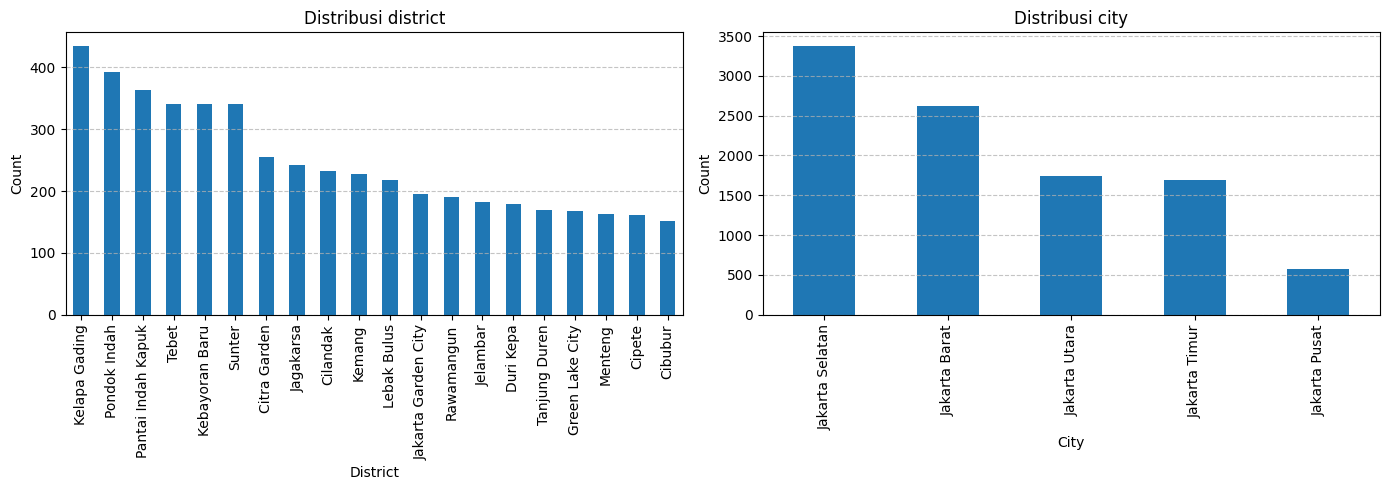

In [8]:
JUMLAH_DISTRICT = 20
JUMLAH_CITY = 5

print(f"Jumlah kategori pada kolom district adalah: {len(df['district'].unique())}")
print(f"Jumlah kategori pada kolom city adalah: {len(df['city'].unique())}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1
df["district"].value_counts().head(JUMLAH_DISTRICT).plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_xlabel("District")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribusi district")
axes[0].grid(axis="y", alpha=0.75, linestyle="--")

# Plot 2
df["city"].value_counts().head(JUMLAH_CITY).plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_xlabel("City")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribusi city")
axes[1].grid(axis="y", alpha=0.75, linestyle="--")

plt.tight_layout()
plt.show()

Beberapa kolom numerik bisa memiliki nilai ekstrem, sehingga histogram menjadi sulit dibaca karena sebagian besar data terlihat menumpuk di area kecil.

Gunakan flag `ENABLE_99_PERCENTILE_LIMIT` untuk memilih tampilan plot. Set menjadi `True` jika ingin membatasi x-axis sampai percentile tertentu, atau `False` jika ingin melihat seluruh range data.

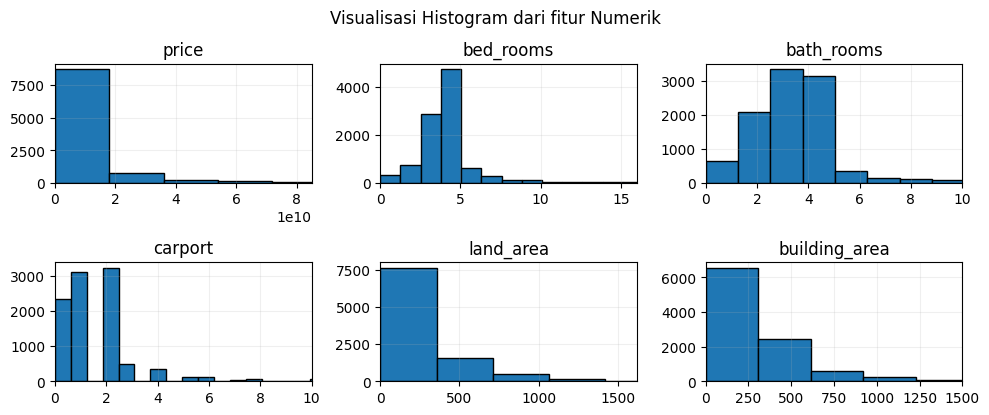

In [9]:
# TODO: lengkapi kode berikut untuk mengatur plot histogram

ENABLE_99_PERCENTILE_LIMIT = True

# fitur numerik
columns = ["price", "bed_rooms", "bath_rooms", "carport", "land_area", "building_area"]

X_AXIS_PERCENTILE = 0.99

fig, axes = plt.subplots(4, 3, figsize=(10, 8))
axes = axes.flatten()

for ax, col in zip(axes, columns):
    ax.hist(df[col].dropna(), bins=50, edgecolor="black")

    if ENABLE_99_PERCENTILE_LIMIT:
        x_max = df[col].quantile(X_AXIS_PERCENTILE)
        ax.set_xlim(left=0, right=x_max)

    ax.set_title(col)
    ax.grid(alpha=0.2)

# remove unused axes
for ax in axes[len(columns):]:
    ax.remove()

plt.suptitle("Visualisasi Histogram dari fitur Numerik")
plt.tight_layout()

Bandingkan nilai quantile untuk melihat sebaran fitur numerik secara lebih ringkas.

Perhatikan jarak antara median, P95, P99, dan nilai maksimum. Jika jaraknya sangat jauh, fitur tersebut kemungkinan memiliki outlier atau distribusi yang sangat skewed.

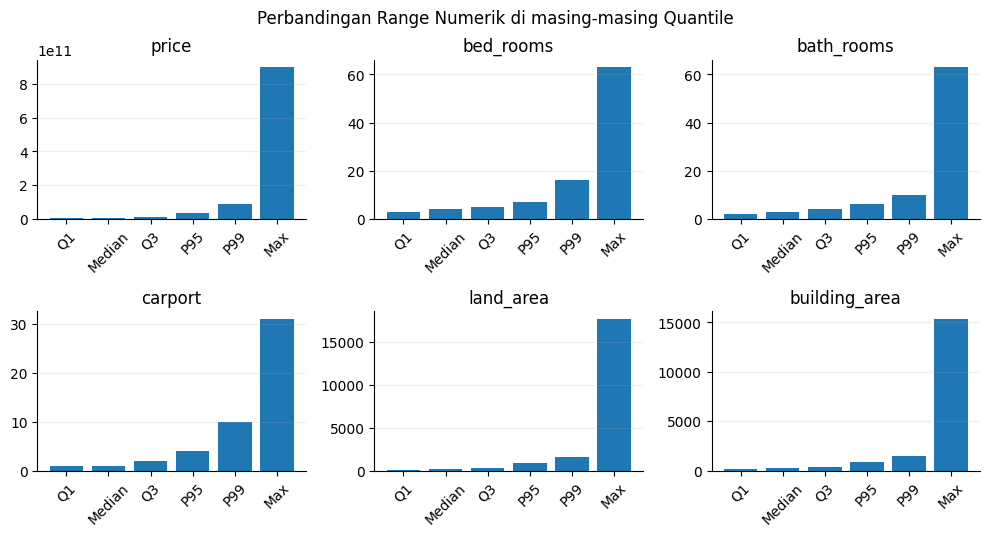

In [10]:
quantiles = [0.25, 0.50, 0.75, 0.95, 0.99, 1.0]
labels = ["Q1", "Median", "Q3", "P95", "P99", "Max"]

fig, axes = plt.subplots(4, 3, figsize=(10, 10))
axes = axes.flatten()

for ax, col in zip(axes, columns):
    values = df[col].quantile(quantiles)

    ax.bar(labels, values)

    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2)

for ax in axes[len(columns):]:
    ax.remove()

plt.suptitle("Perbandingan Range Numerik di masing-masing Quantile")
plt.tight_layout()
plt.show()

Box plot membantu membandingkan sebaran harga antar kota, terutama median, rentang utama data, dan nilai ekstrem.

Variabel `TAMPILKAN_OUTLIER` bisa diubah menjadi `True` atau `False`. Jika `True`, titik outlier akan ditampilkan. Jika `False`, outlier disembunyikan agar perbandingan antar box lebih mudah dibaca.

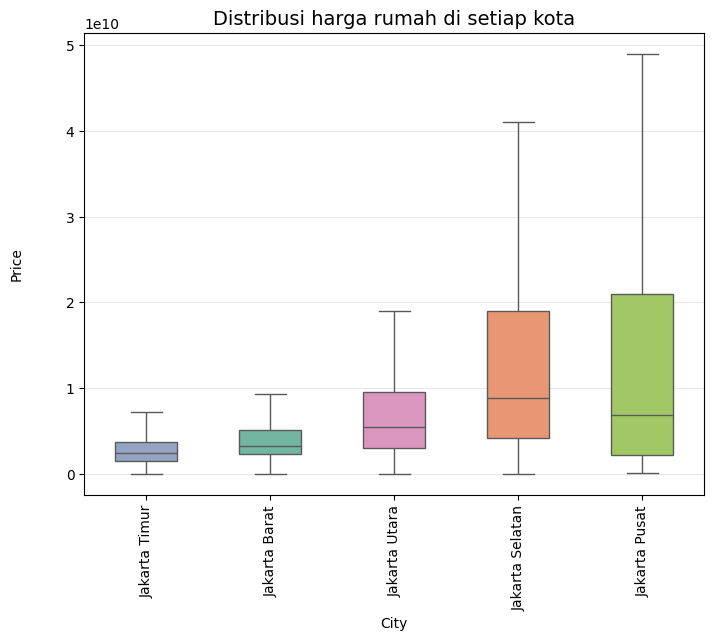

In [11]:
# TODO: lengkapi kode berikut untuk mengatur plot outlier

TAMPILKAN_OUTLIER = False

# menampilkan urutan berdasarkan rata rata harga di setiap kota
order = (
    df.groupby("city")["price"]
    .mean()
    .sort_values()
    .index
)

plt.figure(figsize=(8, 6))

sns.boxplot(
    x="city",
    y="price",
    data=df,
    order=order,
    width=0.5,
    hue="city",
    palette="Set2",
    legend=False,
    showfliers=TAMPILKAN_OUTLIER
)

plt.title("Distribusi harga rumah di setiap kota", fontsize=14)
plt.xticks(rotation=90)
plt.ylabel("Price", labelpad=30)
plt.xlabel("City")
plt.grid(True, axis="y", alpha=0.3)

plt.show()

Korelasi membantu melihat arah dan kekuatan hubungan linear antar fitur numerik. Pada cell ini, angka korelasi dihitung menggunakan Pearson correlation, yaitu perhitungan dari pasangan nilai pada dua kolom, misalnya bagaimana perubahan `land_area` berkaitan dengan perubahan `price`.

Nilai mendekati 1 berarti hubungan positif kuat, mendekati -1 berarti hubungan negatif kuat, dan mendekati 0 berarti hubungan linear lemah. Perhatikan fitur mana yang paling berkaitan dengan `price`, tapi ingat bahwa korelasi tidak selalu berarti sebab-akibat.

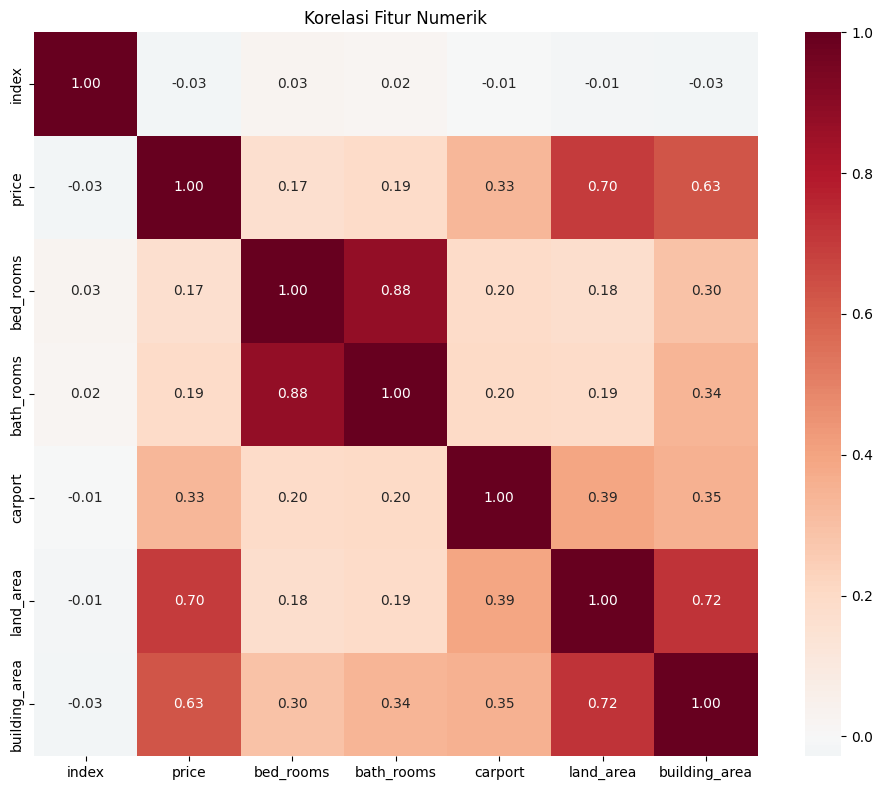

In [12]:
# NOTE: hitung correlation matrix dari dataframe

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
)
plt.title("Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

Sebelum membuat scatter plot, lihat dulu daftar kolom yang tersedia agar bisa memilih fitur yang ingin dibandingkan dengan `price`.

Pada cell berikutnya, nama kolom yang dipilih akan digunakan sebagai sumbu x untuk melihat pola hubungan fitur tersebut dengan harga rumah.

In [13]:
print(f"Kolom yang bisa di coba:\n\n {list(df.columns)}")

Kolom yang bisa di coba:

 ['index', 'price', 'district', 'city', 'bed_rooms', 'bath_rooms', 'carport', 'land_area', 'building_area']


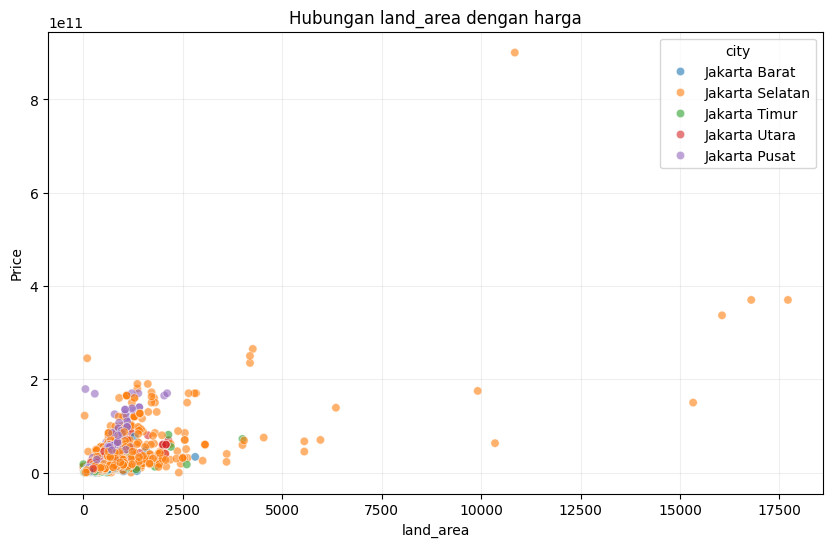

In [14]:
# TODO: kolom yang dapat di isi berdasarkan kolom yang tersedia pada output di atas

X_COLUMN = "land_area"

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x=X_COLUMN,
    y="price",
    hue="city",
    alpha=0.6
)

plt.title(f"Hubungan {X_COLUMN} dengan harga")
plt.xlabel(X_COLUMN)
plt.ylabel("Price")
plt.grid(alpha=0.2)

plt.show()

## Membersihkan Data

Pada tahap membersihkan data, sebaiknya gunakan salinan dataset agar data asli tetap aman.

Dengan begitu, jika ada proses cleaning yang perlu diulang atau dibandingkan, kita masih punya versi awal dataset sebagai referensi.

In [15]:
# TODO: copy dataframe terlebih dahulu supaya dataframe asli (df) tidak berubah

df_clean = df.copy()

In [16]:
print(f"Cek kolom yang perlu di buang:\n\n {list(df_clean.columns)}")

Cek kolom yang perlu di buang:

 ['index', 'price', 'district', 'city', 'bed_rooms', 'bath_rooms', 'carport', 'land_area', 'building_area']


Tidak semua kolom berguna untuk analisis atau model. Kolom yang hanya berfungsi sebagai penanda urutan data biasanya tidak membawa informasi tentang harga rumah.

Hapus kolom yang tidak relevan, lalu cek kembali daftar kolom setelah proses tersebut.

In [17]:
# TODO: buang kolom index, karena kolom tersebut tidak penting bagi model dan analisis

df_clean = df_clean.drop(columns=["index"])

print(f"Cek kolom yang baru:\n\n {list(df_clean.columns)}")

Cek kolom yang baru:

 ['price', 'district', 'city', 'bed_rooms', 'bath_rooms', 'carport', 'land_area', 'building_area']


Missing value perlu dicek sebelum modeling karena beberapa algoritma tidak bisa menerima data kosong.

Hitung jumlah nilai kosong pada setiap kolom, lalu tentukan kolom mana yang perlu ditangani.

In [18]:
# TODO: cek jumlah data kosong di setiap kolom

df_clean.isna().sum()

price            0
district         0
city             0
bed_rooms        0
bath_rooms       0
carport          0
land_area        3
building_area    5
dtype: int64

In [19]:
# tampilkan data yang kosong
df_clean[
    df_clean["land_area"].isna() |
    df_clean["building_area"].isna()
]

,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
1870,38000000000,Menteng,Jakarta Pusat,11,0,0,487.0,NaN
2127,3700000000,Pondok Kelapa,Jakarta Timur,5,4,2,NaN,400.0
2944,4500000000,Kelapa Gading,Jakarta Utara,4,2,0,153.0,NaN
3071,5300000000,Tomang,Jakarta Barat,3,6,0,162.0,NaN
4793,4300000000,Semanan,Jakarta Barat,5,5,2,NaN,192.0
4958,21800000000,Golf Island,Jakarta Utara,7,8,2,NaN,800.0
9405,6800000000,Sunter,Jakarta Utara,4,0,2,180.0,NaN
9785,5300000000,Kelapa Gading,Jakarta Utara,3,2,0,220.0,NaN


Untuk modeling, missing value sebaiknya diisi setelah train-test split supaya statistik seperti median hanya dihitung dari data training.

In [20]:
# kolom numerik yang memiliki missing value
columns_to_fill = ["land_area", "building_area"]

df_clean[columns_to_fill].isna().sum()

land_area        3
building_area    5
dtype: int64

Ada beberapa cara menangani missing value. Isi dengan median, mean, atau mode jika kolom masih penting dan jumlah data kosongnya tidak terlalu besar.

Drop column bisa dipilih jika satu kolom terlalu banyak kosong atau tidak relevan. Drop row bisa dipilih jika jumlah baris yang kosong sangat sedikit dan tidak banyak mengurangi data.

Pada bagian ini, kita coba metode pandas terlebih dahulu untuk mengisi missing value dengan nilai median.

In [21]:
# demonstrasi mengisi missing value dengan pandas fillna + median
# gunakan copy supaya df_clean untuk modeling tidak berubah sebelum train-test split

df_pandas_fill = df_clean.copy()

land_area_median = df_pandas_fill["land_area"].median()
df_pandas_fill["land_area"] = df_pandas_fill["land_area"].fillna(land_area_median)

# TODO: lengkapi median filling untuk kolom building area berdasarkan contoh pada kolom land area

building_area_median = df_pandas_fill["building_area"].median()
df_pandas_fill["building_area"] = df_pandas_fill["building_area"].fillna(building_area_median)

df_pandas_fill[columns_to_fill].isna().sum()

land_area        0
building_area    0
dtype: int64

Setelah mencoba cara manual dengan pandas, kita bandingkan dengan pendekatan dari scikit-learn.

Imputer dari scikit-learn lebih mudah digabungkan ke workflow modeling karena proses menghitung nilai pengisi dan menerapkannya bisa dipisahkan dengan jelas.

In [22]:
from sklearn.impute import SimpleImputer

# copy data untuk demonstrasi cara kerja imputer
# ini belum dipakai untuk modeling
# pada modeling, imputer akan di-fit setelah train-test split
df_imputer = df_clean.copy()

imputer = SimpleImputer(strategy="median")

# lakukan fitting terhadap imputer = proses menghitung strategy
imputer.fit(df_imputer[columns_to_fill])

print(f"Kolom yang masuk kedalam imputer adalah: {imputer.feature_names_in_}")
print(f"Strategy filling yang digunakan adalah: {imputer.strategy}")

Kolom yang masuk kedalam imputer adalah: ['land_area' 'building_area']
Strategy filling yang digunakan adalah: median


In [23]:
print(f"Median yang dihasilkan imputer untuk fitur: {columns_to_fill} adalah:")
print(imputer.statistics_)
print()

print(f"Median yang dihasilkan pandas dataframe untuk fitur: {columns_to_fill} adalah:")
print(df_pandas_fill[columns_to_fill].median())

Median yang dihasilkan imputer untuk fitur: ['land_area', 'building_area'] adalah:
[177. 230.]

Median yang dihasilkan pandas dataframe untuk fitur: ['land_area', 'building_area'] adalah:
land_area        177.0
building_area    230.0
dtype: float64


In [24]:
# lakukan transform = proses filling terjadi
df_imputer[columns_to_fill] = imputer.transform(df_imputer[columns_to_fill])

In [25]:
df_imputer[columns_to_fill].isna().sum()

land_area        0
building_area    0
dtype: int64

## Eksperimen dengan kombinasi fitur (Feature Engineering)

Feature engineering membuat fitur baru dari kolom yang sudah ada agar model mendapat informasi yang lebih bermakna. Fitur tambahan bisa membantu model menangkap pola yang sebelumnya tidak terlihat langsung dari kolom asli.

Karena perhitungan di sini hanya memakai nilai dari baris yang sama, proses ini aman dilakukan sebelum train-test split. 

Buatkan fitur `total_rooms` merangkum jumlah kamar, sedangkan `building_land_ratio` membandingkan luas bangunan dengan luas tanah.

In [26]:
# TODO: membuat fitur baru dari fitur yang sudah ada

# jumlah ruangan di dalam 1 rumah = jumlah ruang tidur + jumlah kamar mandi
df_clean["total_rooms"] = df_clean["bed_rooms"] + df_clean["bath_rooms"]

# rasio luas bangunan dengan luas tanah
df_clean["building_land_ratio"] = df_clean["building_area"] / df_clean["land_area"]

df_clean[["total_rooms", "building_land_ratio"]].head()

,total_rooms,building_land_ratio
0,6,1.400000
1,6,2.250000
2,6,2.333333
3,5,2.000000
4,7,1.928571


In [27]:
# TODO: cek missing value karena kita mengkombinasi missing value

df_clean[["total_rooms", "building_land_ratio"]].isna().sum()

total_rooms            0
building_land_ratio    8
dtype: int64

## Train and Test Splitting

Sebelum membagi data, tentukan dulu mana kolom yang menjadi fitur dan mana kolom yang menjadi target.

Pada kasus regression ini, target adalah nilai yang ingin diprediksi, sedangkan fitur adalah informasi yang digunakan untuk membantu prediksi.

In [28]:
# TODO: pisahkan data fitur dan target fitur

X = df_clean.drop(columns="price")
y = df_clean["price"]

Setelah fitur dan target dipisahkan, data perlu dibagi menjadi data training dan data testing.

Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengevaluasi performa model pada data yang belum pernah dilihat.

In [29]:
from sklearn.model_selection import train_test_split

# TODO: lakukan splitting dan tentukan jumlah data yang akan di jadikan testing

UKURAN_TEST_SET = 0.2 # 20 %

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=UKURAN_TEST_SET,
    random_state=42
)

print(f"Jumlah train set: {len(X_train)}")
print(f"Jumlah test set: {len(X_test)}")

Jumlah train set: 8000
Jumlah test set: 2000


## Mengisi missing menggunakan Imputer

Imputer dilakukan setelah train-test split supaya nilai pengisi seperti median hanya dihitung dari data training. Jika median dihitung dari seluruh dataset, test set ikut memengaruhi proses training dan evaluasi model bisa menjadi kurang jujur.

In [30]:
from sklearn.impute import SimpleImputer

columns_to_fill = ["land_area", "building_area", "building_land_ratio"]

# TODO: lakukan filling terhadap missing value berdasarkan kolom yang sudah di tandai

imputer = SimpleImputer(strategy="median")

# fit hanya pada train
X_train[columns_to_fill] = imputer.fit_transform(
    X_train[columns_to_fill]
)

# test hanya transform menggunakan median dari train
X_test[columns_to_fill] = imputer.transform(
    X_test[columns_to_fill]
)

X_train[columns_to_fill].isna().sum()

land_area              0
building_area          0
building_land_ratio    0
dtype: int64

## Mengubah fitur teks dan kategori

Model machine learning umumnya hanya bisa memproses data dalam bentuk angka, sehingga fitur kategori berbentuk teks perlu diubah menjadi nilai numerik terlebih dahulu.

Ordinal encoder mengubah setiap kategori menjadi angka tertentu. Teknik ini paling cocok digunakan ketika kategori memiliki urutan alami, misalnya rendah, sedang, tinggi. Pada fitur seperti `district`, ordinal encoding bisa digunakan sebagai pendekatan sederhana, tetapi perlu diingat bahwa angka hasil encoding tidak selalu berarti ada urutan kualitas antar lokasi.

In [31]:
from sklearn.preprocessing import OrdinalEncoder

# TODO: lakukan encoding terhadap kolom `district` menggunakan ordinal encoder

ordinal_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# lakukan fitting di training, sekaligus dengan transform
# fitting disini = memproses dan mencatat semua kategori yang ada di data training menjadi angka
X_train[["district"]] = ordinal_encoder.fit_transform(
    X_train[["district"]]
)

# lakukan transform pada test
# transform disini = merubah semua kategori ke angka yang sudah di catat dari data training
X_test[["district"]] = ordinal_encoder.transform(
    X_test[["district"]]
)

encoded_ordinal = ordinal_encoder.get_feature_names_out(["district"])
print(f"fitur yang di encode oleh ordinal encoder: {encoded_ordinal}")

X_train[["district"]].head(5)

fitur yang di encode oleh ordinal encoder: ['district']


,district
9254,197.0
1561,105.0
1670,215.0
6087,230.0
6669,96.0


Kita dapat melihat pasangan kategori beserta angka encoded dari masing masing kategori dari kolom district.

In [32]:
mapping_df = pd.DataFrame({
    "district": ordinal_encoder.categories_[0],
    "encoded_value": range(len(ordinal_encoder.categories_[0]))
})

mapping_df.head(10)

,district,encoded_value
0,Alfa Indah,0
1,Ampera,1
2,Ancol,2
3,Angke,3
4,Antasari,4
5,Bambu Apus,5
6,Bandara,6
7,Bandengan,7
8,Bangka,8
9,Bendungan Hilir,9


One-hot encoding digunakan untuk mengubah fitur kategori menjadi beberapa kolom angka berisi 0 atau 1.

Teknik ini cocok digunakan ketika kategori tidak memiliki urutan alami, seperti nama kota. Dengan one-hot encoding, model tidak menganggap satu kategori lebih tinggi atau lebih rendah dari kategori lain.

In [33]:
from sklearn.preprocessing import OneHotEncoder

# TODO: lakukan encoding terhadap kolom `city` menggunakan one hot encoder

onehot_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

# penjelasan proses fitting dan transform sama seperti ordinal encoder

# fit hanya pada train
train_city_encoded = onehot_encoder.fit_transform(
    X_train[["city"]]
)

# test hanya transform
test_city_encoded = onehot_encoder.transform(
    X_test[["city"]]
)

city_columns = onehot_encoder.get_feature_names_out(["city"])

city_columns

array(['city_Jakarta Barat', 'city_Jakarta Pusat', 'city_Jakarta Selatan',
       'city_Jakarta Timur', 'city_Jakarta Utara'], dtype=object)

Hasil one-hot encoding berbentuk array atau dataframe baru dengan beberapa kolom tambahan, satu kolom untuk setiap kategori.

Berbeda dengan ordinal encoding yang langsung mengganti isi satu kolom, hasil one-hot encoding perlu digabungkan kembali ke dataframe utama agar bisa digunakan bersama fitur lainnya saat training model.

In [34]:
train_city_encoded = pd.DataFrame(
    train_city_encoded,
    columns=city_columns,
    index=X_train.index
)

test_city_encoded = pd.DataFrame(
    test_city_encoded,
    columns=city_columns,
    index=X_test.index
)

In [35]:
# gabungkan ke df_clean

X_train = pd.concat(
    [
        X_train.drop(columns="city"),
        train_city_encoded
    ],
    axis=1
)

X_test = pd.concat(
    [
        X_test.drop(columns="city"),
        test_city_encoded
    ],
    axis=1
)

X_train.head()

,district,bed_rooms,bath_rooms,carport,land_area,building_area,total_rooms,building_land_ratio,city_Jakarta Barat,city_Jakarta Pusat,city_Jakarta Selatan,city_Jakarta Timur,city_Jakarta Utara
9254,197.0,3,2,1,42.0,75.0,5,1.785714,0.0,1.0,0.0,0.0,0.0
1561,105.0,4,3,1,67.0,150.0,7,2.238806,0.0,0.0,0.0,0.0,1.0
1670,215.0,5,5,3,300.0,380.0,10,1.266667,0.0,0.0,0.0,0.0,1.0
6087,230.0,18,18,0,60.0,291.0,36,4.850000,1.0,0.0,0.0,0.0,0.0
6669,96.0,4,3,1,315.0,290.0,7,0.920635,0.0,0.0,1.0,0.0,0.0


## Feature Scaling pada fitur Numerik

Feature scaling adalah proses menyamakan skala nilai antar fitur numerik agar tidak ada fitur yang terlalu mendominasi hanya karena angkanya lebih besar.

Scaling penting terutama untuk model yang sensitif terhadap jarak atau besar kecilnya nilai fitur. Dengan scaling, fitur seperti `land_area`, `building_area`, dan jumlah ruangan bisa dibandingkan dalam skala yang lebih seimbang.

In [36]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 9254 to 7270
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   district              8000 non-null   float64
 1   bed_rooms             8000 non-null   int64  
 2   bath_rooms            8000 non-null   int64  
 3   carport               8000 non-null   int64  
 4   land_area             8000 non-null   float64
 5   building_area         8000 non-null   float64
 6   total_rooms           8000 non-null   int64  
 7   building_land_ratio   8000 non-null   float64
 8   city_Jakarta Barat    8000 non-null   float64
 9   city_Jakarta Pusat    8000 non-null   float64
 10  city_Jakarta Selatan  8000 non-null   float64
 11  city_Jakarta Timur    8000 non-null   float64
 12  city_Jakarta Utara    8000 non-null   float64
dtypes: float64(9), int64(4)
memory usage: 875.0 KB


In [37]:
scaling_columns = [
    "bed_rooms",
    "bath_rooms",
    "carport",
    "land_area",
    "building_area",
    "total_rooms",
    "building_land_ratio",
]

In [38]:
unscaled_data = X_train[scaling_columns]
unscaled_data.describe()

,bed_rooms,bath_rooms,carport,land_area,building_area,total_rooms,building_land_ratio
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4.268625,3.526250,1.584250,296.899125,319.253750,7.794875,1.423842
std,3.259339,2.982142,1.761545,486.827873,358.136134,6.048688,3.861685
min,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000898
25%,3.000000,2.000000,1.000000,100.000000,138.000000,6.000000,0.882353
50%,4.000000,3.000000,1.000000,180.000000,230.000000,7.000000,1.280899
75%,5.000000,4.000000,2.000000,339.000000,400.000000,9.000000,1.718750
max,63.000000,63.000000,31.000000,16791.000000,15331.000000,126.000000,308.000000


Ada beberapa teknik scaling yang bisa digunakan, tergantung karakteristik data dan model yang dipakai.

- Standard Scaler: cocok ketika fitur numerik memiliki skala berbeda dan data tidak perlu dibatasi ke range tertentu. Teknik ini mengubah nilai berdasarkan rata-rata dan standar deviasi.
- MinMax Scaler: cocok ketika kita ingin mengubah nilai ke range tertentu, biasanya 0 sampai 1. Teknik ini lebih sensitif terhadap outlier karena nilai minimum dan maksimum sangat memengaruhi hasil scaling.

Pada dataset ini, beberapa fitur memiliki outlier dan distribusi yang cukup skewed. Karena itu, kita menggunakan Standard Scaler agar skala fitur lebih seimbang tanpa memaksa semua nilai masuk ke range 0 sampai 1.

In [39]:
from sklearn.preprocessing import StandardScaler

# TODO: lakukan scaling terhadap kolom numerik menggunakan standard scaler

scaler = StandardScaler()

# fit hanya menggunakan data training
X_train[scaling_columns] = scaler.fit_transform(
    X_train[scaling_columns]
)

# test hanya menggunakan parameter dari training
X_test[scaling_columns] = scaler.transform(
    X_test[scaling_columns]
)

In [40]:
X_train[scaling_columns].describe()

,bed_rooms,bath_rooms,carport,land_area,building_area,total_rooms,building_land_ratio
count,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03
mean,-3.685940e-17,-2.309264e-17,2.886580e-17,-5.151435e-17,-8.348877e-17,-2.797762e-17,7.815970e-17
std,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00
min,-1.309741e+00,-1.182529e+00,-8.994089e-01,-6.078486e-01,-8.886946e-01,-1.288769e+00,-3.685004e-01
25%,-3.892520e-01,-5.118285e-01,-3.316899e-01,-4.044786e-01,-5.061346e-01,-2.967565e-01,-1.402298e-01
50%,-8.242216e-02,-1.764781e-01,-3.316899e-01,-2.401392e-01,-2.492330e-01,-1.314210e-01,-3.701812e-02
75%,2.244077e-01,1.588722e-01,2.360292e-01,8.648541e-02,2.254765e-01,1.992499e-01,7.637240e-02
max,1.802054e+01,1.994454e+01,1.669988e+01,3.388288e+01,4.191893e+01,1.954350e+01,7.939417e+01


## Training menggunakan Model Linear Regression

Setelah data selesai diproses, kita bisa mulai melatih model regression.

Linear Regression cocok digunakan sebagai baseline model karena sederhana, cepat dilatih, dan mudah diinterpretasikan. Dalam machine learning, kita sebaiknya mulai dari baseline terlebih dahulu agar punya pembanding sebelum mencoba model yang lebih kompleks.

In [41]:
from sklearn.linear_model import LinearRegression

# NOTE: lakukan training model menggunakan linear regression dengan training data

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Evaluasi Model Linear Regression

Evaluasi pada training set digunakan untuk melihat seberapa baik model mempelajari data yang digunakan saat training.

Nilai ini nantinya perlu dibandingkan dengan performa pada test set. Jika performa training jauh lebih baik daripada test, model bisa jadi mengalami overfitting, yaitu terlalu menyesuaikan diri dengan data training tetapi kurang baik saat menghadapi data baru.

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TODO: buatkan fungsi untuk menghitung metriks regression

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    metrics = {
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 6)
    }

    return metrics

In [43]:
# TODO: evaluasi performa model linear regression pada training set

y_train_pred = model.predict(X_train)

calculate_metrics(y_train, y_train_pred)

{'MAE': 5036613343.22, 'RMSE': 12240469375.84, 'R2': 0.525329}

Setelah melihat performa pada training set, evaluasi juga perlu dilakukan pada test set.

Test set berisi data yang tidak digunakan saat training, sehingga hasil evaluasi ini lebih menggambarkan kemampuan model pada data baru. Bandingkan metrik training dan test untuk melihat apakah model cukup general atau mulai menunjukkan tanda overfitting.

In [44]:
# TODO: lakukan prediksi model linear regression dengan test set beserta evaluasi nya

y_pred = model.predict(X_test)

calculate_metrics(y_test, y_pred)

{'MAE': 5193551631.07, 'RMSE': 18475996334.99, 'R2': 0.54247}

Disini kita bisa membuat figure plot dari hasil prediksi model linear regression.

Plot pertama membandingkan harga aktual dengan harga prediksi. Semakin dekat titik-titik ke garis diagonal, semakin dekat prediksi model dengan nilai aslinya.

Plot kedua adalah residual plot, yaitu selisih antara nilai aktual dan prediksi. Residual yang tersebar acak di sekitar garis 0 menunjukkan error yang lebih stabil. Jika terlihat pola tertentu, model mungkin belum menangkap hubungan data dengan baik.

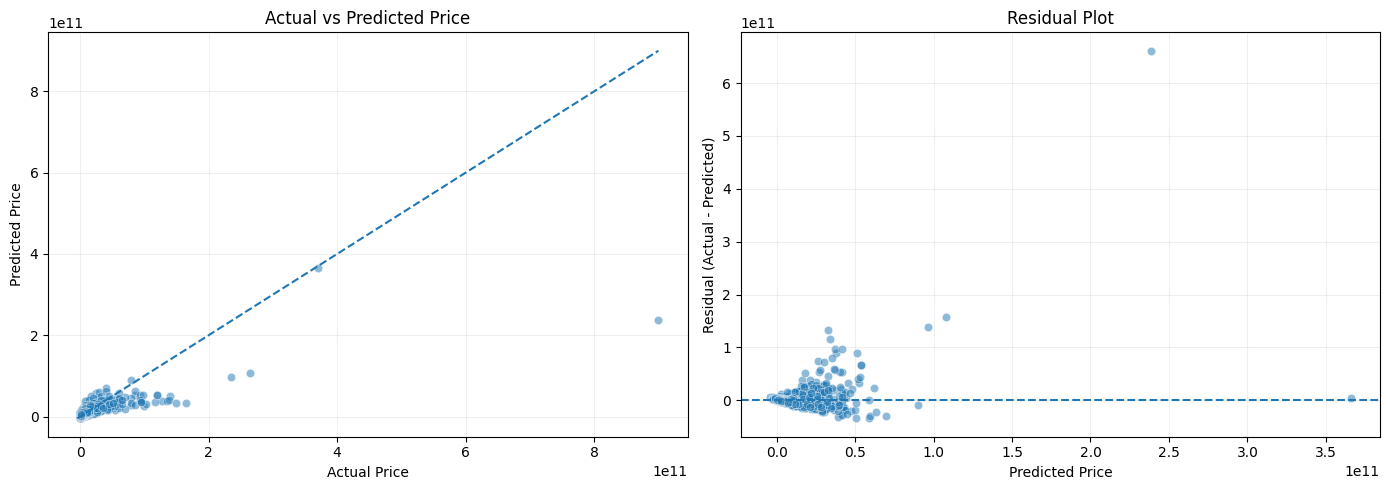

In [45]:
# Residual = nilai aktual - nilai prediksi
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter Plot: Actual vs Predicted Price
sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.5,
    ax=axes[0]
)
# Garis prediksi sempurna: y = x
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

axes[0].plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
axes[0].set_title("Actual vs Predicted Price")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].grid(alpha=0.2)

# 2. Residual Plot
sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.5,
    ax=axes[1]
)
# Garis residual = 0
axes[1].axhline(
    y=0,
    linestyle="--"
)
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted Price")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Membuat Pipeline versi ColumnTransformers

Preprocessing sebelumnya dibuat secara manual agar setiap langkah lebih mudah dipahami.

Namun dalam workflow machine learning yang lebih rapi, preprocessing dan model sebaiknya digabungkan ke dalam pipeline. Dengan pipeline dan ColumnTransformer, proses seperti imputation, encoding, scaling, feature engineering, dan training bisa dijalankan dalam urutan yang konsisten. Ini juga mengurangi risiko lupa menerapkan preprocessing yang sama pada data training, test, atau data baru saat prediksi.

In [46]:
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV

In [47]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X["total_rooms"] = X["bed_rooms"] + X["bath_rooms"]
        X["building_land_ratio"] = X["building_area"] / X["land_area"]

        return X


class HousePriceModel:
    def __init__(self, model=None):
        if model is None:
            model = LinearRegression()

        self.model = model 

        self.base_numeric_features = [
            "bed_rooms",
            "bath_rooms",
            "carport",
            "land_area",
            "building_area"
        ]
        self.engineered_numeric_features = [
            "total_rooms",
            "building_land_ratio"
        ]
        self.numeric_features = self.base_numeric_features + self.engineered_numeric_features
        self.ordinal_features = ["district"]
        self.onehot_features = ["city"]

        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        district_pipeline = Pipeline([
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ])
        city_pipeline = Pipeline([
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])

        preprocessor = ColumnTransformer([
            ("numeric", numeric_pipeline, self.numeric_features),
            ("district", district_pipeline, self.ordinal_features),
            ("city", city_pipeline, self.onehot_features)
        ])

        self.pipeline = Pipeline([
            ("feature_engineering", FeatureEngineer()),
            ("preprocessor", preprocessor),
            ("model", self.model)
        ])

    def train(self,X_train,y_train):
        self.pipeline.fit(X_train,y_train)
        return self

    def tune(
        self,
        X_train,
        y_train,
        param_grid,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    ):
        search = GridSearchCV(
            estimator=self.pipeline,
            param_grid=param_grid,
            cv=cv,
            scoring=scoring,
            n_jobs=n_jobs
        )

        search.fit(X_train, y_train)

        self.pipeline = search.best_estimator_

        return {
            "best_params": search.best_params_,
            "best_score": search.best_score_
        }

    def evaluate(self, X, y):
        y_pred = self.pipeline.predict(X)

        return calculate_metrics(y, y_pred)

    def predict(self, X):
        return self.pipeline.predict(X)

Pada versi pipeline, kita mulai lagi dari data mentah agar seluruh preprocessing dilakukan di dalam pipeline.

Fitur yang dipilih adalah kolom asli dari dataset, sedangkan feature engineering, imputation, encoding, dan scaling akan ditangani otomatis oleh pipeline.

In [48]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("../dataset/jakarta_house.csv")

X = df[["district", "city", "bed_rooms", "bath_rooms", "carport", "land_area", "building_area"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

Model baseline yang sama digunakan kembali, tetapi kali ini dibungkus dalam class pipeline.

Dengan cara ini, training dan evaluasi bisa dilakukan lebih ringkas, sementara urutan preprocessing tetap konsisten untuk training set maupun test set.

In [49]:
from sklearn.linear_model import LinearRegression

USE_MODEL = LinearRegression()

house_model = HousePriceModel(model=USE_MODEL)

house_model.train(X_train, y_train)

print(f"Metriks evaluasi pada training set: {house_model.evaluate(X_train, y_train)}")
print(f"Metriks evaluasi pada test set: {house_model.evaluate(X_test, y_test)}")

Metriks evaluasi pada training set: {'MAE': 5036613343.22, 'RMSE': 12240469375.84, 'R2': 0.525329}
Metriks evaluasi pada test set: {'MAE': 5193551631.07, 'RMSE': 18475996334.99, 'R2': 0.54247}


## Melakukan Prediksi dengan data rumah baru

Setelah pipeline dilatih, kita bisa menggunakannya untuk memprediksi harga rumah baru.

Ubah nilai input pada `new_house` sesuai skenario yang ingin dicoba, misalnya mengganti lokasi, jumlah kamar, luas tanah, atau luas bangunan. Pastikan nama kolom tetap sama seperti fitur yang digunakan saat training.

In [50]:
# NOTE: ubah input untuk mencoba prediksi

new_house = pd.DataFrame({
    "district": ["Tebet"],
    "city": ["Jakarta Selatan"],
    "bed_rooms": [4],
    "bath_rooms": [3],
    "carport": [2],
    "land_area": [150],
    "building_area": [200]
})

prediksi = house_model.predict(new_house)[0]

print(f"harga prediksi rumah sesuai input adalah: {prediksi:,.0f} rupiah")

harga prediksi rumah sesuai input adalah: 10,242,797,915 rupiah


## Eksperimen dengan Model lain dan Hyperparameter Tuning

Dalam machine learning, kita biasanya tidak berhenti pada satu model saja. Model yang berbeda bisa menangkap pola data dengan cara yang berbeda, sehingga kita perlu membandingkan beberapa model untuk melihat mana yang paling cocok dengan dataset dan tujuan prediksi.

Hyperparameter tuning adalah proses mencoba beberapa kombinasi pengaturan model sebelum training, lalu memilih kombinasi yang memberikan performa terbaik. Berbeda dengan parameter yang dipelajari model saat training, hyperparameter ditentukan terlebih dahulu oleh kita.

In [51]:
from sklearn.linear_model import Ridge

USE_MODEL = Ridge()

house_model = HousePriceModel(model=USE_MODEL)

param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

result = house_model.tune(
    X_train,
    y_train,
    param_grid=param_grid,
    cv=5
)

print(result)
print()

print(f"Metriks evaluasi pada training set: {house_model.evaluate(X_train, y_train)}")
print(f"Metriks evaluasi pada test set: {house_model.evaluate(X_test, y_test)}")

{'best_params': {'model__alpha': 1000}, 'best_score': np.float64(-4936228135.687844)}

Metriks evaluasi pada training set: {'MAE': 4898164951.37, 'RMSE': 12377395868.68, 'R2': 0.51465}
Metriks evaluasi pada test set: {'MAE': 5096760684.89, 'RMSE': 18917452087.41, 'R2': 0.520345}


In [52]:
from sklearn.neighbors import KNeighborsRegressor

USE_MODEL = KNeighborsRegressor()

house_model = HousePriceModel(model=USE_MODEL)

param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"]
}

result = house_model.tune(
    X_train,
    y_train,
    param_grid=param_grid,
    cv=5
)

print(result)
print()

print(f"Metriks evaluasi pada training set: {house_model.evaluate(X_train, y_train)}")
print(f"Metriks evaluasi pada test set: {house_model.evaluate(X_test, y_test)}")

{'best_params': {'model__n_neighbors': 7, 'model__weights': 'distance'}, 'best_score': np.float64(-3292521342.8873854)}

Metriks evaluasi pada training set: {'MAE': 22442429.17, 'RMSE': 462430512.75, 'R2': 0.999323}
Metriks evaluasi pada test set: {'MAE': 3398473095.63, 'RMSE': 19267734449.54, 'R2': 0.502418}


In [53]:
print("Congratulations, Regression is Finished!")

Congratulations, Regression is Finished!
